# Phase Identification and Window Segmentation — PhaseNet Method

This notebook implements phase detection using **PhaseNet**, a deep-learning phase picker trained on the **INSTANCE dataset** (Michelini et al., 2021). PhaseNet uses convolutional neural networks to detect P and S arrivals directly from waveforms, without requiring pre-computed features or search windows.

**Comparison with AR-AIC (notebook 03a):**
- **AR-AIC:** Traditional method, requires search windows, processes 3 components together
- **PhaseNet:** Deep learning, no search windows needed, processes each component independently

**Workflow:**
1. **Load PhaseNet model** — Pre-trained INSTANCE model via SeisBench
2. **Resample signals** — 200 Hz → 100 Hz (PhaseNet training rate)
3. **Phase detection** — CNN-based P/S picking on each component
4. **Merge with metadata** — Join picks with station information
5. **Coda onset detection** — Same 4 methods as AR-AIC (Rautian, Arias, Envelope, Median)
6. **Window segmentation** — Create 4 windows: pre-event, P-wave, S-wave, coda
7. **Quality control** — Validate detections (monotonicity, SNR, peak timing)

**Key differences from 03a:**
- No CRUST1.0 queries needed (PhaseNet doesn't use velocity model)
- No adaptive search windows (CNN detects onsets directly)
- Component-level picks (unlike AR-AIC which uses all 3 components together)
- Resampling required (PhaseNet trained on 100 Hz data)

**Dataset:** Same preprocessed signals as notebook 03a (baseline-corrected, unnormalized).

**Key references:**
- Zhu & Beroza (2019) — PhaseNet original paper
- Woollam et al. (2022) — SeisBench framework
- Michelini et al. (2021) — INSTANCE dataset

**Outputs:**
- `df_full_{signal_type}_phasenet.parquet` — Complete metadata with PhaseNet picks
- `windowed_{signal_type}_{coda_method}_phasenet.pkl` — Segmented signals (4 files)
- `phasenet_picks_{signal_type}.csv` — Raw PhaseNet output
- Validation plots in `figures/03b_phase_identification_phasenet/{signal_type}/`

## 1. Imports and visualization settings

In [28]:
import seisbench
import seisbench.models as sbm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
import sys
import pickle
from pathlib import Path
from src  import (
    apply_phasenet_to_signals,
    set_plot_style,
    add_hypocentral_distance,
    expand_to_component_level,
    add_coda_onsets_to_dataframe,
    segment_all_signals,
    quality_control_all_stations,
    print_quality_control_summary,
    add_time_columns,
    convert_signals_to_dict,
    validate_signals_dict,
    merge_phasenet_picks_with_metadata,
    add_coda_end_to_dataframe,
    get_station_from_filename,
    plot_onset_detection_results,
    plot_multiple_stations,
    add_crustal_velocities,
    add_theoretical_arrivals
)
colors, colors1 = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Configuration

Set `DATA_TYPE` to process acceleration, velocity, or displacement signals. The configuration automatically determines:
- Signal column name
- Physical units
- Peak ground motion columns (PGA/PGV/PGD)

PhaseNet can be applied to all three signal types, though it was originally trained on velocity waveforms.

In [29]:
# CONFIGURATION
# EVENT_ID = 'INT-41004391'
EVENT_ID = 'IT-2009-0009'
DATA_TYPE = 'velocity'  # Options: 'acceleration', 'velocity', 'displacement'

# Determine signal column name and units based on DATA_TYPE
if DATA_TYPE == 'acceleration':
    SIGNAL_COLUMN = 'acceleration'
    SIGNAL_UNIT = 'cm/s²'
    PEAK_COLUMN = 'PGA_CM/S^2'
    TIME_PEAK_COLUMN = 'TIME_PGA_S'
elif DATA_TYPE == 'velocity':
    SIGNAL_COLUMN = 'velocity'
    SIGNAL_UNIT = 'cm/s'
    PEAK_COLUMN = 'PGV_CM/S'
    TIME_PEAK_COLUMN = 'TIME_PGV_S'
elif DATA_TYPE == 'displacement':
    SIGNAL_COLUMN = 'displacement'
    SIGNAL_UNIT = 'cm'
    PEAK_COLUMN = 'PGD_CM'
    TIME_PEAK_COLUMN = 'TIME_PGD_S'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

logger.info(f"Working with {DATA_TYPE} data")
logger.info(f"Signal column: {SIGNAL_COLUMN}")
logger.info(f"Peak column: {PEAK_COLUMN}")

INFO | Working with velocity data
INFO | Signal column: velocity
INFO | Peak column: PGV_CM/S


## 3. Data Loading

Load preprocessed signals and metadata:
- **Signals:** Baseline-corrected but **not normalized** (preserves waveform morphology for PhaseNet)
- **Metadata:** Station coordinates, epicentral distances, event parameters

**Note:** Unlike traditional pickers, PhaseNet can work with normalized signals, but unnormalized data preserves amplitude information that may improve performance.

In [30]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Define all paths from project root with DATA_TYPE subdirectories
METADATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '01a_metadata' / DATA_TYPE
SIGNALS_PROCESSED_IMPORT = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '01b_signals' / DATA_TYPE
SIGNALS_PROCESSED_EXPORT = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / '03b_phase_identification_phasenet' / DATA_TYPE
FIGURES_DIR = PROJECT_ROOT / 'figures' / EVENT_ID / '03b_phase_identification_phasenet' / DATA_TYPE
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / EVENT_ID / 'latex_tables' / DATA_TYPE

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PROCESSED.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_IMPORT.mkdir(parents=True, exist_ok=True)
SIGNALS_PROCESSED_EXPORT.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(SIGNALS_PROCESSED_EXPORT.exists(), f"Exported signals directory ready: {SIGNALS_PROCESSED_EXPORT}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(METADATA_PROCESSED.exists(), f"Processed metadata directory ready: {METADATA_PROCESSED}")
check(SIGNALS_PROCESSED_IMPORT.exists(), f"Processed signals directory ready: {SIGNALS_PROCESSED_IMPORT}")

# Load metadata
logger.info(f"Loading {DATA_TYPE} metadata...")
df_meta = pd.read_parquet(METADATA_PROCESSED / f'metadata_clean_{DATA_TYPE[:3]}.parquet')
check(df_meta is not None, "Metadata loaded successfully")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata loaded, shape: {df_meta.shape}")

# Load signals
logger.info(f"Loading {DATA_TYPE} signals...")
df_signals = pd.read_parquet(SIGNALS_PROCESSED_IMPORT / f'{DATA_TYPE[:3]}_preprocessed_scaling.parquet')
check(df_signals is not None, "Signals loaded successfully")
check(len(df_signals) > 0, "Signals dataframe is not empty")
logger.info(f"Signals loaded, shape: {df_signals.shape}")
logger.info(f"Unique files: {df_signals['file'].nunique()}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/IT-2009-0009/03b_phase_identification_phasenet/velocity
INFO | Exported signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/03b_phase_identification_phasenet/velocity
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/latex_tables/velocity
INFO | Processed metadata directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01a_metadata/velocity
INFO | Processed signals directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/01b_signals/velocity
INFO | Loading velocity metadata...
INFO | Metadata loaded successfully
INFO | Metadata dataframe is not empty
INFO | Metadata loaded, shape: (192, 38)
INFO | Loading velocity signals...
INFO

## 4. Metadata Preparation

Reduce metadata to **1 row per station** (removing component replication). This station-level DataFrame will be expanded back to component-level after PhaseNet detection.

**Note:** Unlike AR-AIC (which requires crustal velocities and search windows), PhaseNet operates directly on waveforms without prior velocity model information.

In [31]:
logger.info("Preparing station metadata (1 row per station)...")

# Select essential columns and reduce to 1 row per station
df_meta_stations = df_meta.drop_duplicates('STATION_CODE')[[
    'STATION_CODE',
    'STATION_LATITUDE_DEGREE',
    'STATION_LONGITUDE_DEGREE',
    'EPICENTRAL_DISTANCE_KM',
    'INSTRUMENTAL_FREQUENCY_HZ',
    'LOW_CUT_FREQUENCY_HZ',
    'HIGH_CUT_FREQUENCY_HZ',
    PEAK_COLUMN,
    TIME_PEAK_COLUMN,
    'EVENT_DATE',
    'EVENT_DEPTH_KM',
    'DATE_TIME_FIRST_SAMPLE'
]].copy()

logger.info("Calculating hypocentral distance for QC...")
hypo_depth_km = df_meta_stations['EVENT_DEPTH_KM'].iloc[0]
df_meta_stations = add_hypocentral_distance(
    df_meta_stations,
    hypo_depth_km=hypo_depth_km,
    distance_col='EPICENTRAL_DISTANCE_KM'
)

check('hypocentral_distance_km' in df_meta_stations.columns, "Hypocentral distance calculated")

n_stations = len(df_meta_stations)
logger.info(f"Station metadata ready: {n_stations} unique stations")

# Display first rows
print("\nFirst 5 stations:")
display(df_meta_stations.head())

# Summary statistics
print("\nEpicentral distance range:")
print(f"  Min: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].min():.2f} km")
print(f"  Max: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].max():.2f} km")
print(f"  Median: {df_meta_stations['EPICENTRAL_DISTANCE_KM'].median():.2f} km")

INFO | Preparing station metadata (1 row per station)...
INFO | Calculating hypocentral distance for QC...
INFO | Hypocentral distance calculated
INFO | Station metadata ready: 64 unique stations


Hypocentral distance calculated:
Hypocenter depth: 8.30 km
Epicentral distance:  min=1.80, median=137.65, max=421.40 km
Hypocentral distance: min=8.49, median=137.90, max=421.48 km
Depth correction:     min=0.08, median=0.25, max=6.69 km

First 5 stations:


,STATION_CODE,STATION_LATITUDE_DEGREE,STATION_LONGITUDE_DEGREE,EPICENTRAL_DISTANCE_KM,INSTRUMENTAL_FREQUENCY_HZ,LOW_CUT_FREQUENCY_HZ,HIGH_CUT_FREQUENCY_HZ,PGV_CM/S,TIME_PGV_S,EVENT_DATE,EVENT_DEPTH_KM,DATE_TIME_FIRST_SAMPLE,hypocentral_distance_km
0,SANL,40.252750,16.271763,335.4,200.0,0.05,25.0,-0.973200,93.520,2009-04-06 01:32:40,8.3,2009-04-06 01:33:16,335.502683
3,TTS,40.601345,15.723605,275.1,200.0,0.04,25.0,-0.722433,74.395,2009-04-06 01:32:40,8.3,2009-04-06 03:27:18,275.225181
6,ANT,42.418200,13.078600,26.2,216.0,0.10,40.0,-1.799668,40.200,2009-04-06 01:32:40,8.3,2009-04-06 01:32:16,27.483268
9,AQA,42.375500,13.339300,5.0,206.0,0.10,40.0,-31.915751,17.910,2009-04-06 01:32:40,8.3,2009-04-06 01:32:27,9.689685
12,AQG,42.373700,13.337000,5.0,202.0,0.10,40.0,-30.959166,32.965,2009-04-06 01:32:40,8.3,2009-04-06 01:32:12,9.689685



Epicentral distance range:
  Min: 1.80 km
  Max: 421.40 km
  Median: 137.65 km


## 5. Crustal Velocity Estimation

Although PhaseNet does **not require** crustal velocities for phase detection (it learns features directly from waveforms), we compute CRUST1.0 velocities here for **quality control** purposes:
- Compare PhaseNet picks vs. theoretical arrivals
- Assess velocity model accuracy
- Identify systematic biases

See notebook `03a_phase_identification_ar_pick` for detailed explanation of CRUST1.0 querying.

In [32]:
# Extract hypocenter depth (assuming single event)
hypo_depth = df_meta_stations['EVENT_DEPTH_KM'].iloc[0]

# Add crustal velocities (vp_crust, vs_crust)
df_meta_stations = add_crustal_velocities(
    df_meta_stations,
    hypo_depth_km=hypo_depth,
    lat_col='STATION_LATITUDE_DEGREE',
    lon_col='STATION_LONGITUDE_DEGREE'
)
check('vp_crust' in df_meta_stations.columns, "vp_crust column added")
check('vs_crust' in df_meta_stations.columns, "vs_crust column added")

INFO | vp_crust column added
INFO | vs_crust column added


Loading CRUST1.0 model...
Querying 64 stations...
Using hypocenter depth: 8.3 km
Added vp_crust, vs_crust, and traversed_layers columns
v_P: min=5.37, mean=5.93, median=6.01, max=6.17 km/s
v_S: min=3.02, mean=3.42, median=3.48, max=3.58 km/s

Unique layer combinations used: 4
  44 stations: ['upper_sediments', 'upper_crust', 'middle_crust (partial)']
  10 stations: ['upper_sediments', 'middle_sediments', 'lower_sediments', 'upper_crust', 'middle_crust (partial)']
   9 stations: ['upper_sediments', 'middle_sediments', 'upper_crust', 'middle_crust (partial)']
   1 station: ['upper_crust', 'middle_crust (partial)']


## 6. Theoretical Arrival Times

Compute theoretical P/S arrivals using CRUST1.0 velocities (same as notebook 03a). These are used **only for validation**, not for guiding PhaseNet detection.

**Key difference from AR-AIC:**
- AR-AIC: theoretical times define **search windows** → required for detection
- PhaseNet: theoretical times only for **comparison** → optional for validation

See notebook 03a for detailed formulas and methodology.

In [33]:
missing_time = df_meta_stations[df_meta_stations['DATE_TIME_FIRST_SAMPLE'].isna()]
if len(missing_time) > 0:
    logger.warning(f"Excluding {len(missing_time)} stations with missing DATE_TIME_FIRST_SAMPLE: {missing_time['STATION_CODE'].tolist()}")
    df_meta_stations = df_meta_stations[df_meta_stations['DATE_TIME_FIRST_SAMPLE'].notna()].copy()

WARNING | Excluding 1 stations with missing DATE_TIME_FIRST_SAMPLE: ['GSG']


In [34]:
logger.info("Calculating theoretical arrival times...")

# Add theoretical arrivals (t_p_theo, t_s_theo)
df_meta_stations = add_theoretical_arrivals(
    df_meta_stations,
    hypo_depth_km=hypo_depth,
    distance_col='EPICENTRAL_DISTANCE_KM'
)

check('t_p_theo_seconds' in df_meta_stations.columns, "t_p_theo_seconds column added")
check('t_s_theo_seconds' in df_meta_stations.columns, "t_s_theo_seconds column added")
check('t_p_theo_samples' in df_meta_stations.columns, "t_p_theo_samples column added")
check('t_s_theo_samples' in df_meta_stations.columns, "t_s_theo_samples column added")

# Summary
print("\nTheoretical arrival time ranges:")
print(f"  P-wave: {df_meta_stations['t_p_theo_seconds'].min():.2f} - {df_meta_stations['t_p_theo_seconds'].max():.2f} s")
print(f"  S-wave: {df_meta_stations['t_s_theo_seconds'].min():.2f} - {df_meta_stations['t_s_theo_seconds'].max():.2f} s")

INFO | Calculating theoretical arrival times...
INFO | t_p_theo_seconds column added
INFO | t_s_theo_seconds column added
INFO | t_p_theo_samples column added
INFO | t_s_theo_samples column added


Hypocentral distance and theoretical arrival times:
Hypocenter depth: 8.30 km
Epicentral distance:  min=1.80, median=137.80, max=421.40 km
Hypocentral distance: min=8.49, median=138.05, max=421.48 km
Depth correction:     min=0.08, median=0.25, max=6.69 km
Origin time: min=-6878.00, max=48.00 s
t_P:         min=-6832.62, max=61.85 s
t_S:         min=-6799.83, max=72.06 s

Theoretical arrival time ranges:
  P-wave: -6832.62 - 61.85 s
  S-wave: -6799.83 - 72.06 s


## 7. Load PhaseNet Model — INSTANCE Pre-trained

Load the **PhaseNet model pre-trained on INSTANCE dataset** via SeisBench framework.

### PhaseNet Architecture

PhaseNet (Zhu & Beroza, 2019) is a deep convolutional neural network (CNN) for seismic phase detection:

**Input:** 3-component waveform (HNE, HNN, HNZ) at 100 Hz
**Output:** 3 probability time series:
- P-wave probability $P(t)$ — likelihood of P-wave onset at each time $t$
- S-wave probability $S(t)$ — likelihood of S-wave onset
- Noise probability $N(t)$ — likelihood of noise (no phase)

**Architecture:**
- **Encoder:** 5 convolutional layers → downsample waveform, extract features
- **Bottleneck:** Dense layer → compress feature space
- **Decoder:** 5 transpose-convolutional layers → upsample to original time resolution
- **Output:** Softmax layer → 3 probability channels (P, S, N)

**Key features:**
- U-Net structure (encoder-decoder with skip connections)
- Trained end-to-end (no hand-crafted features)
- Processes entire waveform in one forward pass (no sliding window)
- Outputs continuous probability functions (not just single onset times)

### INSTANCE Dataset

INSTANCE (Italian Seismic dataset for machine learning) contains:
- **~54,000 waveforms** from Italian Seismic Network
- **Magnitude range:** 3.0-6.5
- **Distance range:** 0-400 km
- **Manual phase picks** by expert analysts (ground truth)

**Why INSTANCE for this study?**
- Regional/local earthquakes (similar to our Mw 3.8 event)
- Italian geology (Alps, sedimentary basins) → matches our study area
- Strong-motion data included → suitable for accelerograms

### Pre-trained Model

```python
model = sbm.PhaseNet.from_pretrained("instance")
```

**Model details:**
- Trained on INSTANCE waveforms at **100 Hz**
- 3-component input required (vertical + 2 horizontal)
- No fine-tuning applied (transfer learning from INSTANCE → our data)

**Performance (INSTANCE test set):**
- P-wave detection: ~98% recall, ~0.2s mean absolute error
- S-wave detection: ~95% recall, ~0.3s mean absolute error

### Inference Process

1. **Resample** original signal (200 Hz → 100 Hz)
2. **Normalize** by trace maximum (standard PhaseNet preprocessing)
3. **Pad** if needed (PhaseNet requires minimum 3000 samples = 30s at 100 Hz)
4. **Forward pass** through network → probability functions $P(t)$, $S(t)$, $N(t)$
5. **Peak detection:** Find maximum probability above threshold
   - Default thresholds: $P(t) > 0.1$ for P, $S(t) > 0.07$ for S
6. **Convert** onset indices back to original time base (account for resampling + offset)

### Advantages vs. Traditional Methods

**PhaseNet strengths:**
- No velocity model required
- No search windows needed
- Handles complex waveforms (emergent arrivals, noise)
- Consistent performance across distance/magnitude
- Trained on large dataset (generalizes well)

**PhaseNet limitations:**
- Requires resampling to 100 Hz (may introduce artifacts)
- Black-box model (hard to interpret failures)
- No uncertainty quantification (single probability peak)
- Performance depends on training data similarity

### References

**Zhu, W., & Beroza, G. C.** (2019). *PhaseNet: a deep-neural-network-based seismic arrival-time picking method.* Geophysical Journal International, 216(1), 261-273. DOI: [10.1093/gji/ggy423](https://doi.org/10.1093/gji/ggy423)

**Woollam, J., et al.** (2022). *SeisBench—A Toolbox for Machine Learning in Seismology.* Seismological Research Letters, 93(3), 1695-1709. DOI: [10.1785/0220210324](https://doi.org/10.1785/0220210324)

**Michelini, A., et al.** (2021). *INSTANCE—the Italian Seismic dataset for machine learning.* Earth System Science Data, 13, 5509-5544. DOI: [10.5194/essd-13-5509-2021](https://doi.org/10.5194/essd-13-5509-2021)

In [35]:
logger.info("Loading PhaseNet model pre-trained on INSTANCE...")
model = sbm.PhaseNet.from_pretrained("instance")
check(model is not None, "PhaseNet model loaded successfully")

INFO | Loading PhaseNet model pre-trained on INSTANCE...
INFO | PhaseNet model loaded successfully


## 8. Phase Picking with PhaseNet

Apply PhaseNet to all signals with automatic resampling to 100 Hz (model training rate).

### Resampling Strategy

**Original data:** 200 Hz  
**PhaseNet input:** 100 Hz (decimation factor = 2)

**Resampling method:** Fourier-domain resampling (anti-aliasing)
1. Apply low-pass filter at Nyquist frequency (50 Hz)
2. Decimate by factor of 2
3. Preserve phase information

**Why 100 Hz?**
- PhaseNet trained on 100 Hz data (INSTANCE standard)
- Running on 200 Hz would require re-training
- 100 Hz sufficient for regional phases (main energy < 20 Hz)

### Detection Thresholds

**Probability thresholds:**
- `min_p_probability = 0.1` — Accept P picks with $P(t_{\\max}) > 0.1$
- `min_s_probability = 0.07` — Accept S picks with $S(t_{\\max}) > 0.07$

**Threshold selection rationale:**
- Lower thresholds → higher recall (fewer missed phases) but more false positives
- Higher thresholds → higher precision but more missed phases
- Default values (0.1 for P, 0.07 for S) balance recall/precision

**S-wave threshold lower than P:**
S-waves are typically more emergent and harder to detect → lower threshold compensates.

### Quality Filtering

After detection, picks are filtered to remove:
1. **Missing onsets:** Stations where $P(t)$ or $S(t)$ never exceeded threshold (NaN)
2. **Invalid ordering:** Stations where $t_S \leq t_P$ (physically impossible)
3. **Low confidence:** (Optional) stations with very low max probabilities

**Expected failure rate:** ~5-15% of stations (distant, low SNR, complex waveforms)

### Output Format

PhaseNet picks are stored with:
- **Onset times:** `t_p_seconds`, `t_s_seconds`, `t_p_samples`, `t_s_samples`
- **Probabilities:** `p_probability_max`, `s_probability_max` (confidence scores)
- **Station info:** `station_code`, `component`

**Dual representation:** Both sample indices (for slicing) and seconds (for visualization).

In [36]:
# Phase picking with PhaseNet
logger.info(f"Starting PhaseNet inference on {DATA_TYPE} signals...")

df_picks = apply_phasenet_to_signals(
    df_signals=df_signals,
    model=model,
    signal_column=SIGNAL_COLUMN,
    sampling_rate_original=200,
    sampling_rate_target=100,
    min_p_probability=0.1,
    min_s_probability=0.07
)

logger.info(f"PhaseNet inference complete: {len(df_picks)} stations processed")

# Quality check and filtering
logger.info("Checking PhaseNet picks quality...")

# Check for invalid picks (S before or at P)
invalid_picks = df_picks[df_picks['t_s_seconds'] <= df_picks['t_p_seconds']]
if len(invalid_picks) > 0:
    logger.warning(f"{len(invalid_picks)} stations with S ≤ P")
    logger.warning(str(invalid_picks[['station_code', 't_p_seconds', 't_s_seconds']]))

# Filter out stations with missing onsets (NaN)
n_before = len(df_picks)
df_picks = df_picks[
    df_picks['t_p_seconds'].notna() & 
    df_picks['t_s_seconds'].notna()
].copy()
n_after = len(df_picks)

if n_before > n_after:
    logger.warning(f"Filtered out {n_before - n_after} station(s) with missing onsets")
else:
    logger.info("All picks valid (no missing onsets)")

# Extract valid station list
valid_stations = df_picks['station_code'].unique().tolist()

# Summary
logger.info(f"\nPhaseNet picks summary:")
logger.info(f"  Valid stations: {len(valid_stations)}")
logger.info(f"  Mean P probability: {df_picks['p_probability_max'].mean():.3f}")
logger.info(f"  Mean S probability: {df_picks['s_probability_max'].mean():.3f}")
logger.info(f"  Mean S-P time: {(df_picks['t_s_seconds'] - df_picks['t_p_seconds']).mean():.2f}s")

# Save cleaned results
output_path = SIGNALS_PROCESSED_EXPORT / f'phasenet_picks_{DATA_TYPE}.csv'
df_picks.to_csv(output_path, index=False)
logger.info(f"\nSaved: {output_path}")

INFO | Starting PhaseNet inference on velocity signals...
WARNING | Skipping SANL: S probability too low (0.012 < 0.07)
WARNING | Skipping ASS: S probability too low (0.004 < 0.07)
WARNING | Skipping AVL: P probability too low (0.019 < 0.1)
WARNING | Skipping BBN: P probability too low (0.002 < 0.1)
WARNING | Skipping BDT: S probability too low (0.026 < 0.07)
WARNING | Skipping BNE: P probability too low (0.034 < 0.1)
WARNING | Skipping BOJ: S probability too low (0.003 < 0.07)
WARNING | Skipping CAN: S probability too low (0.002 < 0.07)
WARNING | Skipping CDS: S probability too low (0.015 < 0.07)
WARNING | Skipping CER: S probability too low (0.022 < 0.07)
WARNING | Skipping CHT: S probability too low (0.027 < 0.07)
WARNING | Skipping CMB: P probability too low (0.074 < 0.1)
WARNING | Skipping CMR: S probability too low (0.002 < 0.07)
WARNING | Skipping CNM: S probability too low (0.001 < 0.07)
WARNING | Skipping CSO1: S probability too low (0.051 < 0.07)
WARNING | Skipping CSS: S pro

## 9. Merge PhaseNet Picks with Metadata

Combine PhaseNet phase picks with station metadata to create a complete DataFrame for analysis.

### Merging Process

The merge operation:
1. **Joins** PhaseNet picks (station-level) with metadata (station-level)
2. **Calculates** origin time from first sample timestamp and event time
3. **Adds** epicentral distance, PGA/PGV/PGD, filter parameters
4. **Preserves** all PhaseNet probability scores

**Key difference from AR-AIC:**
PhaseNet outputs are **already station-level** (no multi-component combination needed), so the merge is simpler.

### Origin Time Calculation

Origin time ($t_0$) is the time from first sample to earthquake origin:

$$t_0 = (T_{\text{event}} - T_{\text{first sample}}) \times 1\text{ second}$$

where:
- $T_{\text{event}}$ = earthquake origin time (from catalog)
- $T_{\text{first sample}}$ = timestamp of first sample in recording

**Purpose:** Convert absolute timestamps to relative times (needed for theoretical arrival calculations).

### Residual Calculation

Compute residuals between PhaseNet picks and CRUST1.0 theoretical arrivals:

$$
\begin{aligned}
\Delta t_P &= t_{P,\text{PhaseNet}} - t_{P,\text{theo}} \\\\
\Delta t_S &= t_{S,\text{PhaseNet}} - t_{S,\text{theo}}
\end{aligned}
$$

**Expected residuals:**
- **Systematic bias:** PhaseNet typically picks **3-5 seconds early** (trained on manually picked catalogs, which tend to pick at signal onset rather than first break)
- **Standard deviation:** ±0.5-1.5 seconds (picking uncertainty + velocity model error)

**Interpretation:**
- Negative residuals → PhaseNet picks earlier than theoretical
- Positive residuals → PhaseNet picks later than theoretical
- Large scatter → velocity model inaccurate or complex wave propagation

### Output Columns

The merged DataFrame contains:
- **Metadata:** Station coordinates, distances, PGA/PGV/PGD
- **PhaseNet picks:** `t_p_seconds`, `t_s_seconds` (both samples and seconds)
- **Theoretical arrivals:** `t_p_theo_seconds`, `t_s_theo_seconds`
- **Residuals:** `p_residual`, `s_residual`
- **Confidence scores:** `p_probability_max`, `s_probability_max`
- **Crustal velocities:** `vp_crust`, `vs_crust` (for QC)

In [37]:
logger.info("Merging PhaseNet picks with station metadata...")

df_meta_stations = merge_phasenet_picks_with_metadata(df_picks, df_meta_stations, sampling_rate=200)

check(len(df_meta_stations) > 0, f"Metadata merged: {len(df_meta_stations)} stations")
check('origin_time_seconds' in df_meta_stations.columns, "origin_time calculated from metadata")

logger.info(f"Origin time range: {df_meta_stations['origin_time_seconds'].min():.2f}s - {df_meta_stations['origin_time_seconds'].max():.2f}s")

INFO | Merging PhaseNet picks with station metadata...
INFO | Metadata merged: 17 stations
INFO | origin_time calculated from metadata
INFO | Origin time range: -6878.00s - 48.00s


In [38]:
# Calculate residuals
logger.info("Calculating onset residuals...")

# P residuals
df_meta_stations['p_residual_seconds'] = (
    df_meta_stations['t_p_detected_seconds'] - 
    df_meta_stations['t_p_theo_seconds']
)

# S residuals
df_meta_stations['s_residual_seconds'] = (
    df_meta_stations['t_s_detected_seconds'] - 
    df_meta_stations['t_s_theo_seconds']
)

df_meta_stations.loc[
    df_meta_stations['t_p_theo_seconds'] < 0, 'p_residual_seconds'
] = np.nan
df_meta_stations.loc[
    df_meta_stations['t_s_theo_seconds'] < 0, 's_residual_seconds'
] = np.nan

# Summary
logger.info(f"\nResidual statistics:")
logger.info(f"  P residual: {df_meta_stations['p_residual_seconds'].mean():+.2f} ± {df_meta_stations['p_residual_seconds'].std():.2f} s")
logger.info(f"  S residual: {df_meta_stations['s_residual_seconds'].mean():+.2f} ± {df_meta_stations['s_residual_seconds'].std():.2f} s")
logger.info(f"  P range: [{df_meta_stations['p_residual_seconds'].min():+.2f}, {df_meta_stations['p_residual_seconds'].max():+.2f}] s")
logger.info(f"  S range: [{df_meta_stations['s_residual_seconds'].min():+.2f}, {df_meta_stations['s_residual_seconds'].max():+.2f}] s")

check('p_residual_seconds' in df_meta_stations.columns, "p_residual_seconds column added")
check('s_residual_seconds' in df_meta_stations.columns, "s_residual_seconds column added")

INFO | Calculating onset residuals...
INFO | 
Residual statistics:
INFO |   P residual: -3.67 ± 0.51 s
INFO |   S residual: +11.44 ± 55.04 s
INFO |   P range: [-4.58, -2.49] s
INFO |   S range: [-4.38, +217.78] s
INFO | p_residual_seconds column added
INFO | s_residual_seconds column added


## 10. Convert Signals to Dictionary

Convert long-format DataFrame to nested dictionary structure for efficient windowing operations.

**Structure:**
```python
signals_dict = {
    'STATION_HNE.ASC': array([...]),  # 1D numpy array per file
    'STATION_HNN.ASC': array([...]),
    'STATION_HNZ.ASC': array([...]),
    ...
}
```

This format is required by `segment_all_signals()` and `add_coda_onsets_to_dataframe()`.

In [40]:
logger.info("Adding time column to signals...")
df_signals = add_time_columns(
    df_signals, 
    df_meta, 
    time_col='DATE_TIME_FIRST_SAMPLE',
    sampling_interval_col='SAMPLING_INTERVAL_S'
)
check('time' in df_signals.columns, "Time column added to signals")

# Filter signals to only include valid stations
logger.info(f"Filtering signals to valid stations ({len(valid_stations)} stations)...")

df_signals = df_signals[
    df_signals['file'].apply(get_station_from_filename).isin(valid_stations)
].copy()

n_total_rows = len(df_signals)
df_signals = df_signals[
    df_signals['file'].apply(get_station_from_filename).isin(valid_stations)
].copy()
logger.info(f"Filtered signals: {len(df_signals)} rows (from {n_total_rows} total)")

# Convert DataFrame to dict
signals_dict = convert_signals_to_dict(df_signals,
                                       signal_column=SIGNAL_COLUMN)

check(len(signals_dict) > 0, "Signals dictionary created")
logger.info(f"Dictionary contains {len(signals_dict)} stations")

# Validate structure
print("\nValidating signals dictionary...")
report = validate_signals_dict(signals_dict)

check(report['valid'], "All signals validated successfully")

# Save signals_dict for sensitivity analysis
output_file = SIGNALS_PROCESSED_EXPORT / f'signals_{DATA_TYPE}_dict.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(signals_dict, f)
logger.info(f"Saved signals_dict: {output_file}")
logger.info(f"File size: {output_file.stat().st_size / 1e6:.2f} MB")

INFO | Adding time column to signals...


Added relative time column (t=0 at first sample)
Sampling rate: 200.0 Hz (interval: 0.005 s)
Relative time range: 0.000 - 312.385 s


INFO | Time column added to signals
INFO | Filtering signals to valid stations (17 stations)...



Added absolute time column
Absolute time range: 2009-04-06 01:31:52 to 2009-04-06 03:29:57.985000
Signal duration: min=39.99, median=100.09, max=312.38 s (51 files)


INFO | Filtered signals: 1170891 rows (from 1170891 total)


Converting 51 files to nested dictionary...
Signal column: 'velocity'


INFO | Signals dictionary created
INFO | Dictionary contains 17 stations
INFO | All signals validated successfully
INFO | Saved signals_dict: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/03b_phase_identification_phasenet/velocity/signals_velocity_dict.pkl
INFO | File size: 12.49 MB


Converted 51 files
Stations: 17
Components per station: {3}

Validating signals dictionary...
All 17 stations validated


## 11. Expand DataFrame to Component Level

Expand station-level DataFrame (1 row per station) to **component-level** (3 rows per station: HNE, HNN, HNZ) to accommodate coda onset times.

**Why expand?**
- PhaseNet picks are station-level (network outputs single P/S time per station)
- Coda detections are component-level (envelope/energy may differ across components)
- Moment scaling treats components as independent ensemble members

**Process:**
1. Replicate each station row 3 times
2. Add `STREAM_COMPONENT` column (HNE, HNN, HNZ)
3. Update `file` column to match original filenames
4. Preserve all PhaseNet pick columns (same for all 3 components per station)

**Result:** `df_full` with `N_stations × 3` rows, ready for coda onset addition.

**Note:** PhaseNet processes components together internally but outputs single onset per station, unlike AR-AIC which explicitly uses multi-component characteristic functions.

In [41]:
logger.info("Expanding metadata to component level...")

# Filter df_meta to only include valid stations
df_meta_valid = df_meta[df_meta['STATION_CODE'].isin(valid_stations)].copy()
logger.info(f"Filtered df_meta: {len(df_meta_valid)} components ({len(df_meta)} total)")

# Expand using filtered metadata
df_full = expand_to_component_level(df_meta_stations, df_meta_valid)

# Dynamic check based on valid_stations
expected_components = len(valid_stations) * 3
check(
    len(df_full) == expected_components, 
    f"Expanded to component level: {len(df_full)} components "
    f"(expected {expected_components} from {len(valid_stations)} stations)"
)

logger.info(f"Component-level DataFrame shape: {df_full.shape}")

INFO | Expanding metadata to component level...
INFO | Filtered df_meta: 51 components (192 total)
INFO | Expanded to component level: 51 components (expected 51 from 17 stations)
INFO | Component-level DataFrame shape: (51, 67)


Expanded onset DataFrame to component level:
  17 stations → 51 components
  (3 components per station)

Columns added:
  - t_coda_rautian, t_coda_arias, t_coda_envelope (initialized as NaN)
  - s_duration_rautian, s_duration_arias, s_duration_envelope (initialized as NaN)


## 12. Coda Onset Detection

Detect coda onsets using the **same four methods** as notebook 03a:

1. **Rautian (1978)** — Theoretical: $t_{\text{coda}} = 2 \times t_S - t_0$
2. **Arias Intensity (D5-95)** — Energy-based: 95% cumulative energy threshold
3. **Envelope Decay** — Amplitude-based: envelope drops below 25% of peak
4. **Median** — Robust combination: median of the three methods above

**Why same methods?**
To enable **direct comparison** of moment scaling results between AR-AIC and PhaseNet. Using identical coda detection ensures differences arise only from P/S picking, not from window definition.

### Expected Coda Onset Differences

Because PhaseNet picks P and S **earlier** than AR-AIC (typically 3-5 seconds), coda onsets will also be earlier:

- **Rautian method:** Directly depends on $t_S$ → systematic shift of ~3-5s earlier
- **Arias method:** Independent of picks (uses full waveform) → no systematic shift
- **Envelope method:** Depends on S-window definition → similar shift to Rautian
- **Median:** Intermediate behavior

**Implication for moment scaling:**
PhaseNet-based windows may include **more S-wave energy in coda window** due to early picks. This could affect coda scaling exponents ζ(q).

### Implementation

See notebook **03a Section 8.2** for detailed explanation of each coda detection method, including:
- Physical basis
- Algorithm details
- Advantages and limitations
- Expected performance

The implementation here is **identical** to 03a — only the input onset times differ.

In [42]:
logger.info("Calculating coda onsets for all methods...")

# Check for missing onsets
n_total = len(df_full)
n_missing_p = df_full['t_p_detected_seconds'].isna().sum()
n_missing_s = df_full['t_s_detected_seconds'].isna().sum()

if n_missing_p > 0 or n_missing_s > 0:
    logger.warning(f"Missing onsets: P={n_missing_p}, S={n_missing_s}")
    logger.warning("Filtering out components with missing onsets...")
    
    df_full_valid = df_full[
        df_full['t_p_detected_seconds'].notna() & 
        df_full['t_s_detected_seconds'].notna()
    ].copy()
    
    logger.info(f"Valid components: {len(df_full_valid)}/{n_total}")
else:
    df_full_valid = df_full.copy()

# Coda detection
df_full = add_coda_onsets_to_dataframe(
    df_full_valid, 
    signals_dict,
    threshold_arias=0.95,
    threshold_envelope=0.3,
    sampling_rate=200,
    unit='samples'
)

check('t_coda_rautian_seconds' in df_full.columns, "Coda onsets computed")
logger.info("Coda onsets computed for all methods: rautian, arias, envelope, median")

# Summary
print("\nCoda onset summary (mean S-wave duration):")
for method in ['rautian', 'arias', 'envelope', 'median']:
    col = f's_duration_{method}_seconds'
    if col in df_full.columns:
        mean_dur = df_full[col].mean()
        std_dur = df_full[col].std()
        print(f"  {method.capitalize():10s}: {mean_dur:.2f} ± {std_dur:.2f}s")

INFO | Calculating coda onsets for all methods...
INFO | Coda onsets computed
INFO | Coda onsets computed for all methods: rautian, arias, envelope, median


Pre-computing Rautian coda onset per station (dual representation)...
Computed Rautian for 17 stations
Calculating Arias, Envelope, and Median coda onsets for 51 components...

Coda onsets computed for 51/51 components (0 failed)
  Created columns with dual representation (_samples + _seconds)
  Legacy columns (no suffix) point to: samples

Coda onset summary (mean S-wave duration):
  Rautian   : 425.38 ± 1631.71s
  Arias     : 24.97 ± 52.05s
  Envelope  : 14.62 ± 22.61s
  Median    : 20.60 ± 30.70s


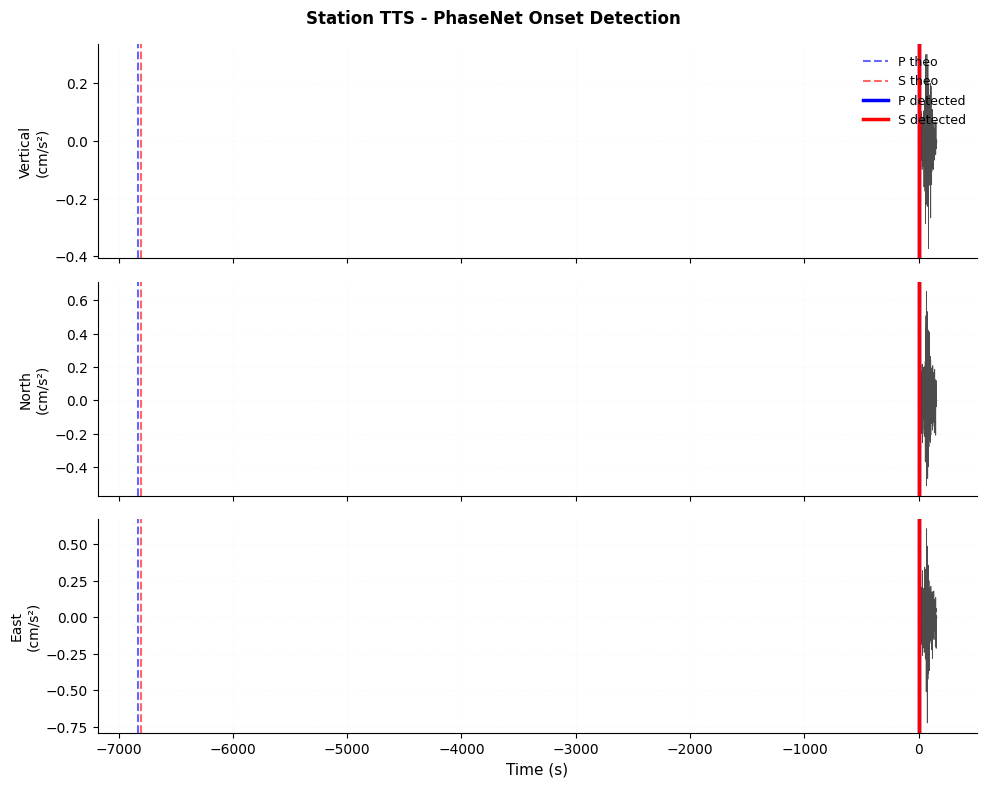

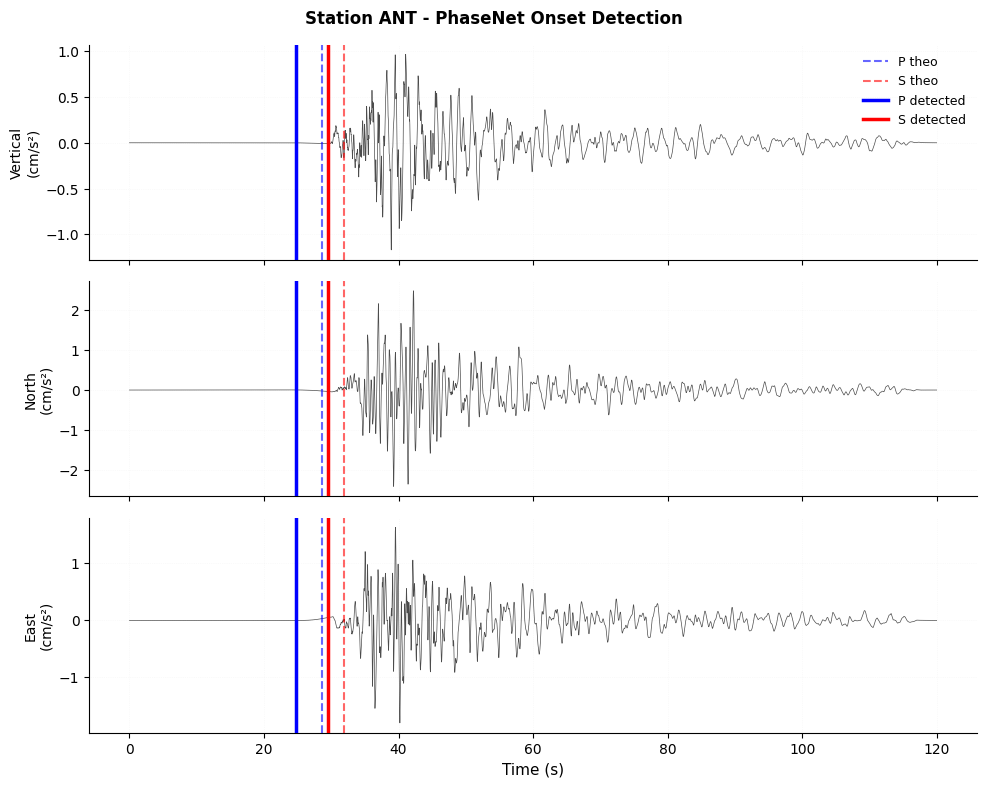

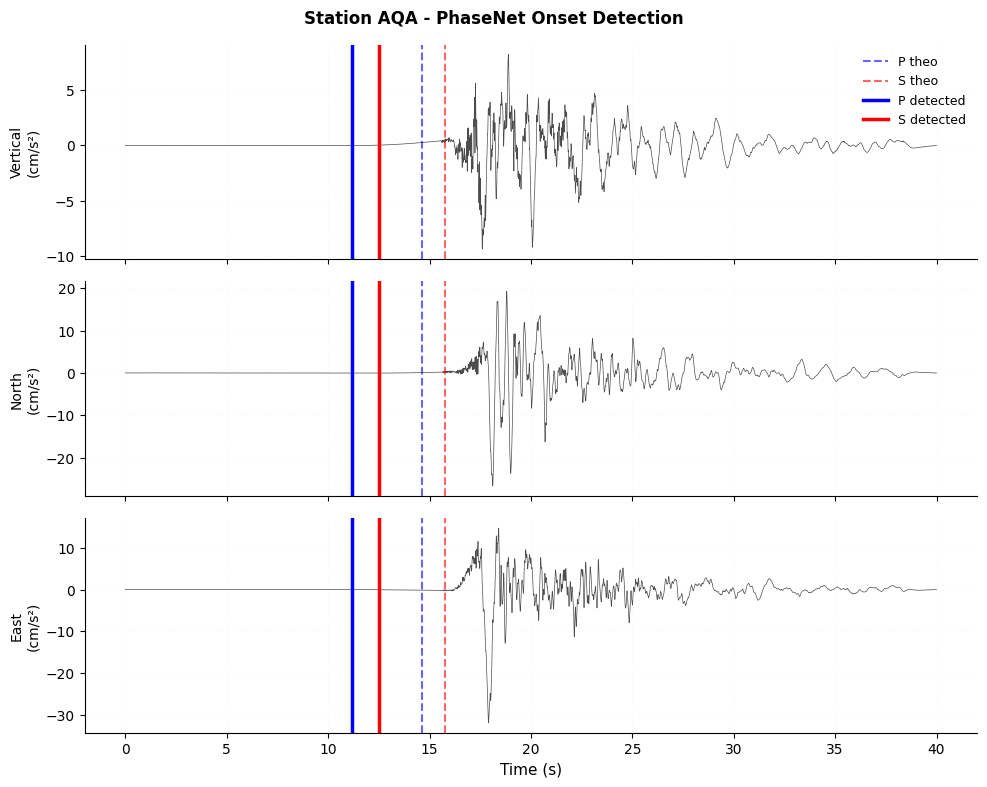

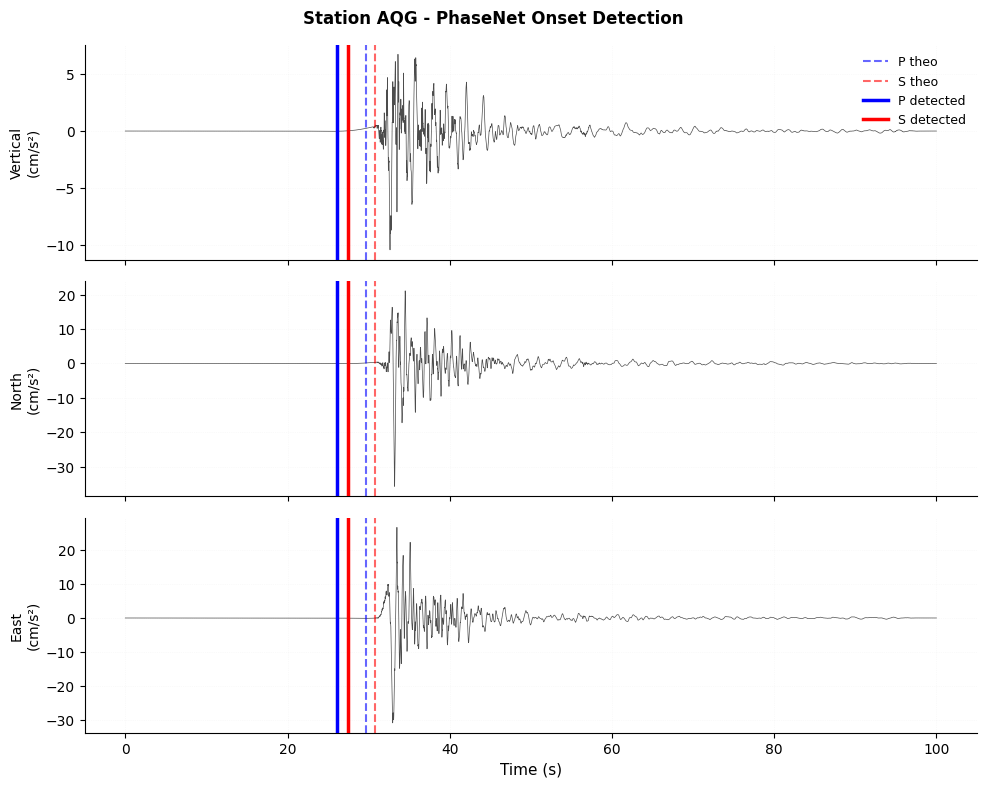

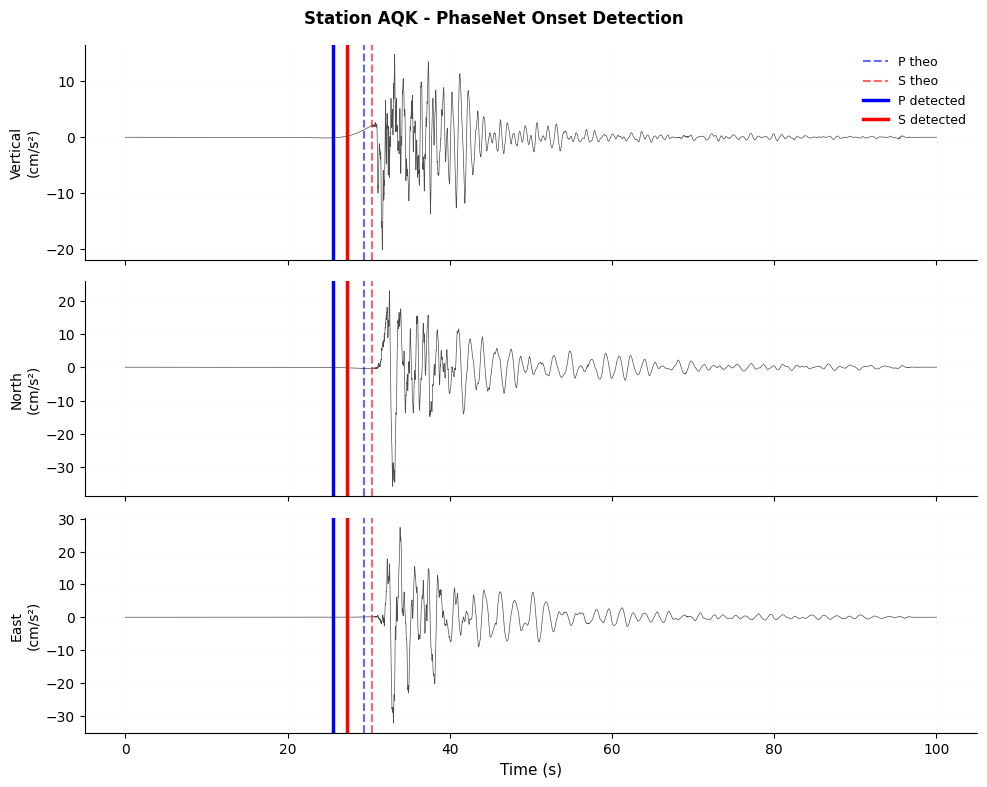

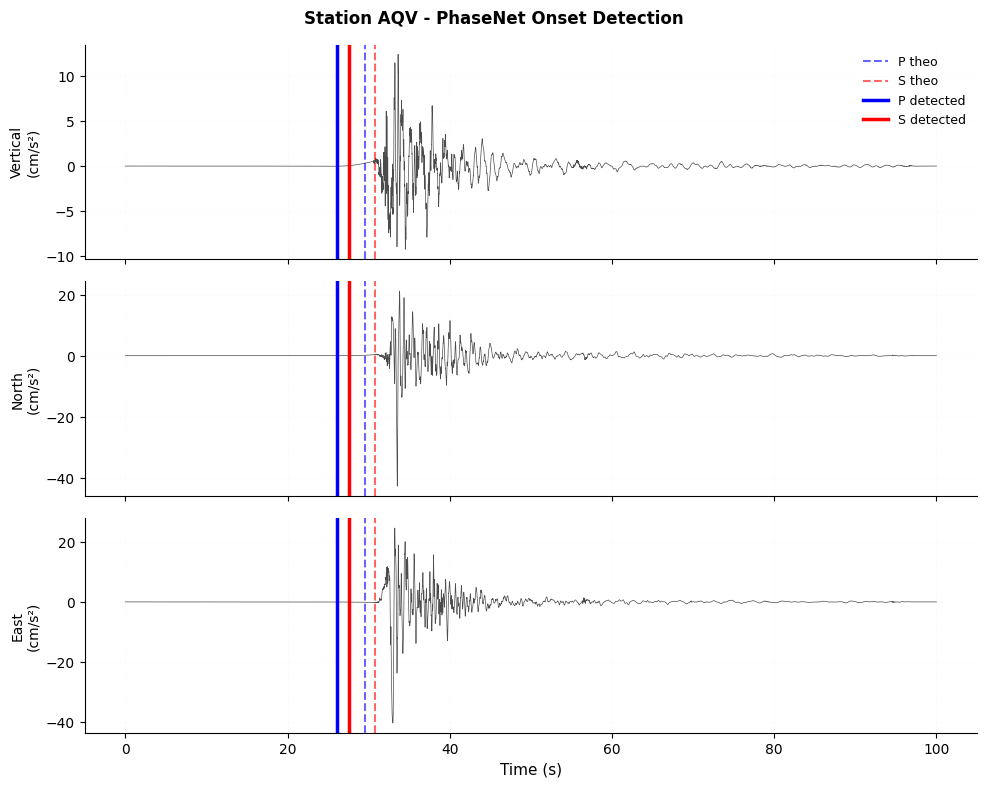

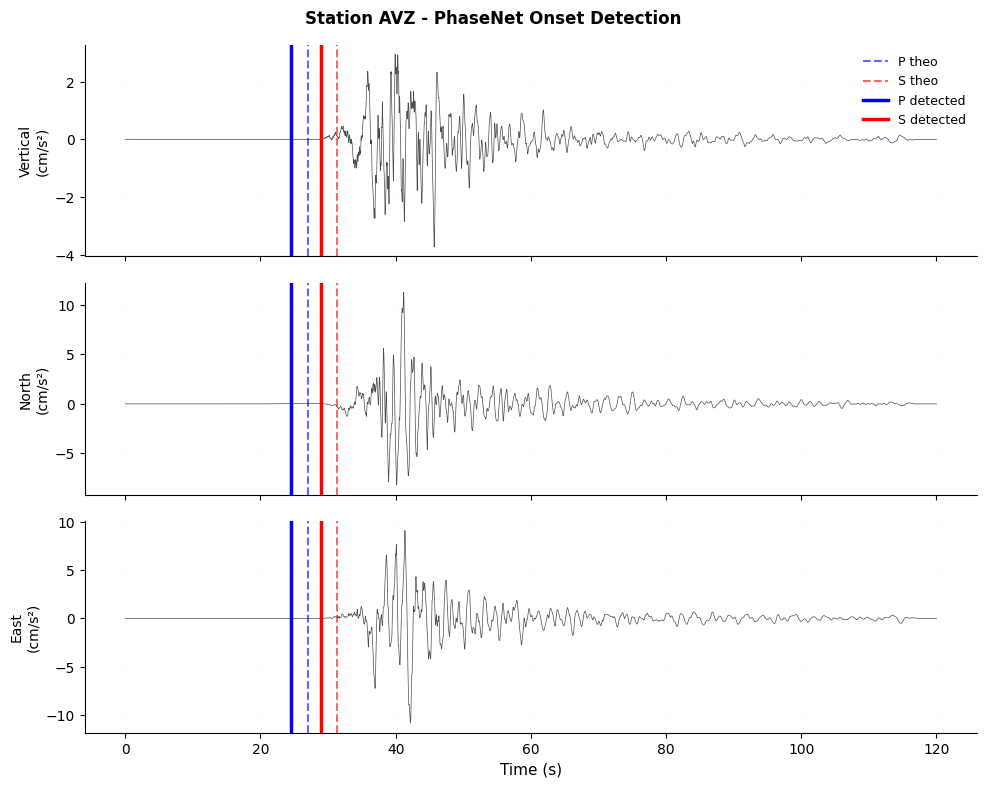

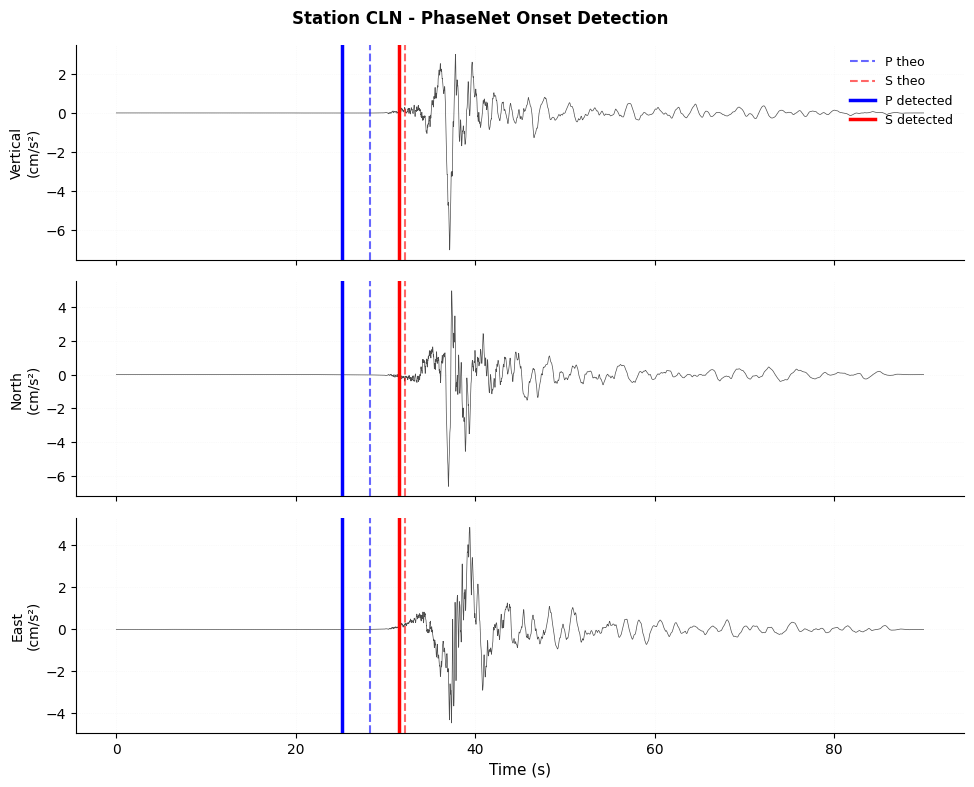

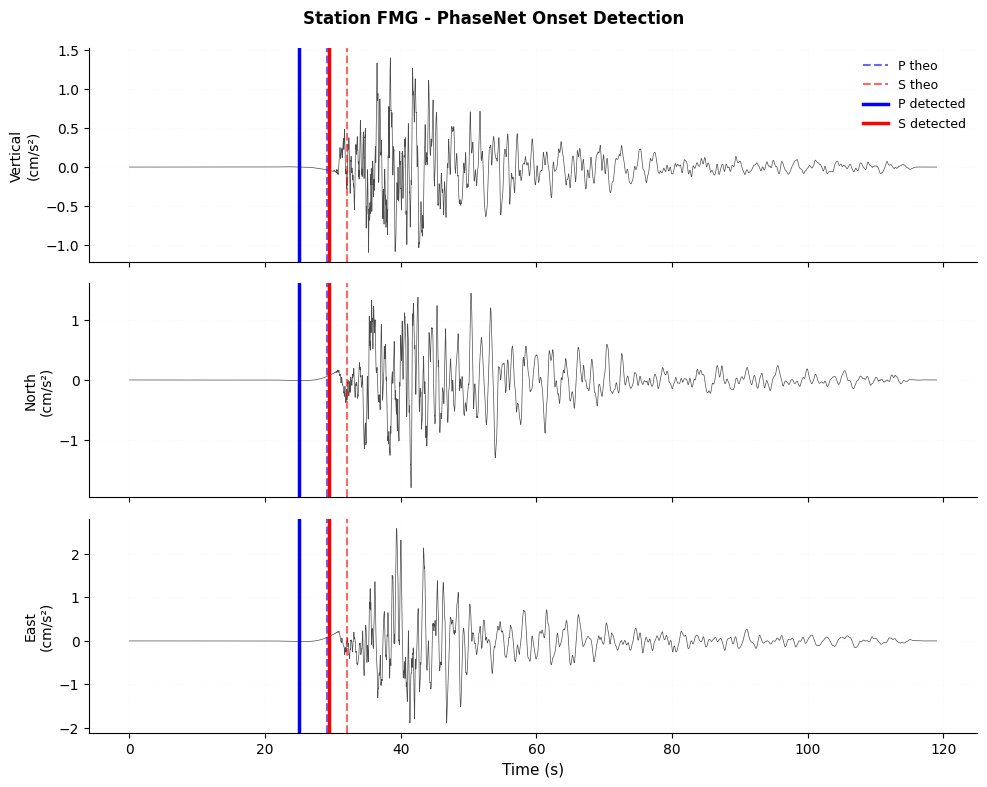

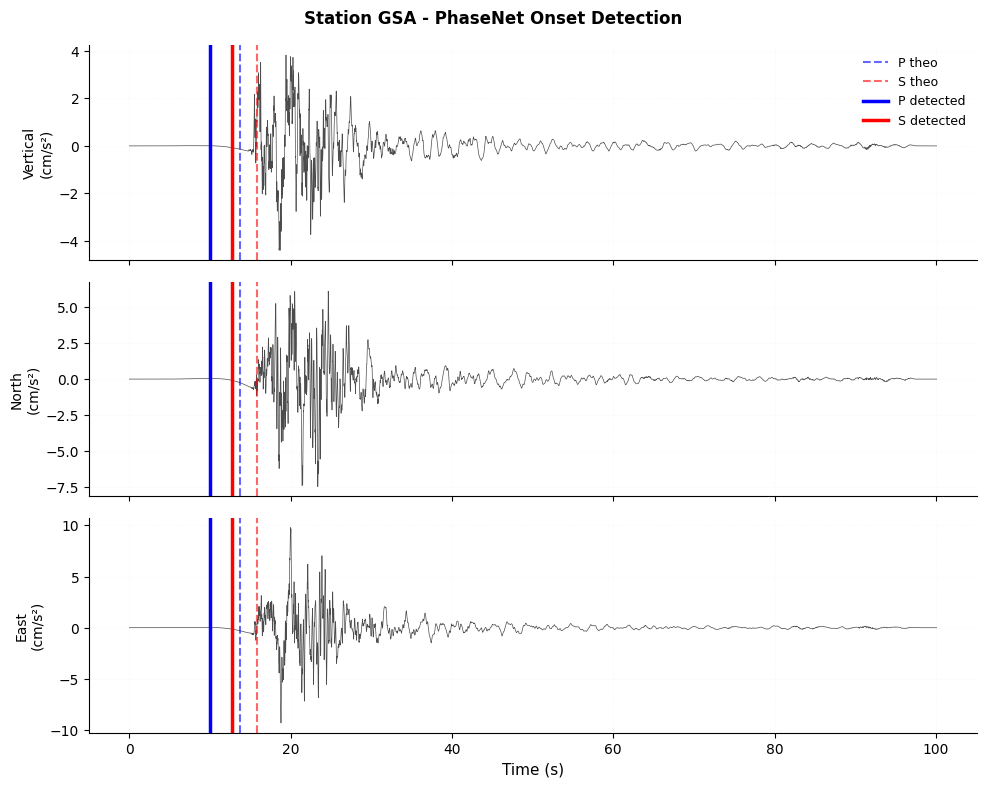

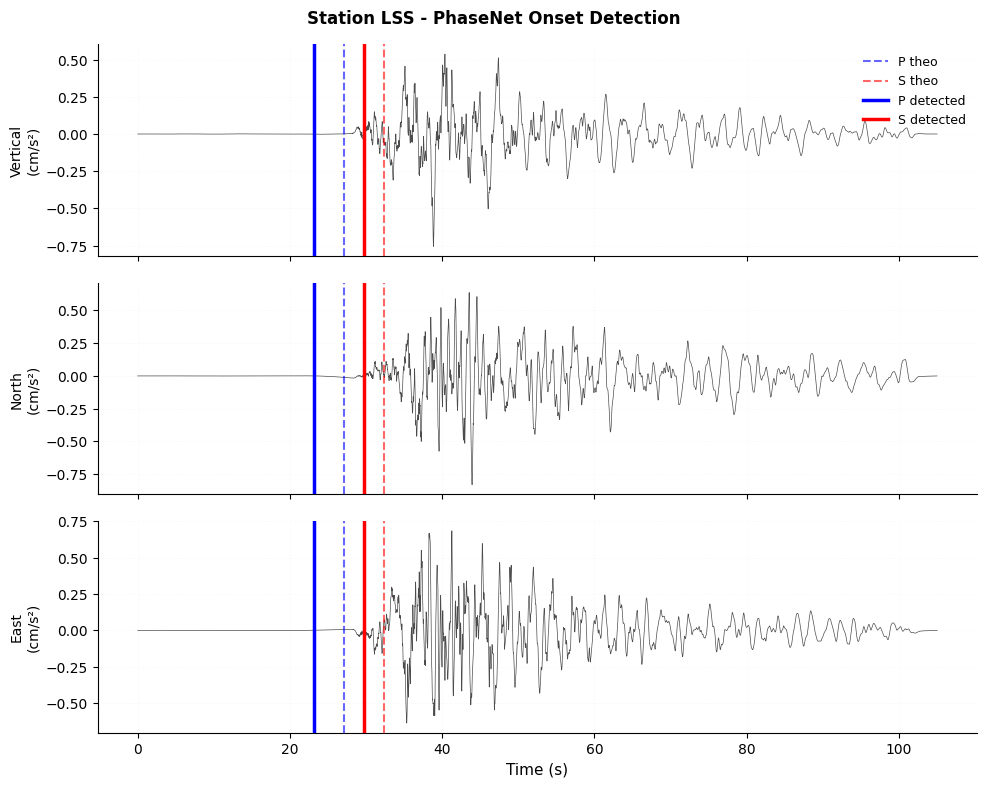

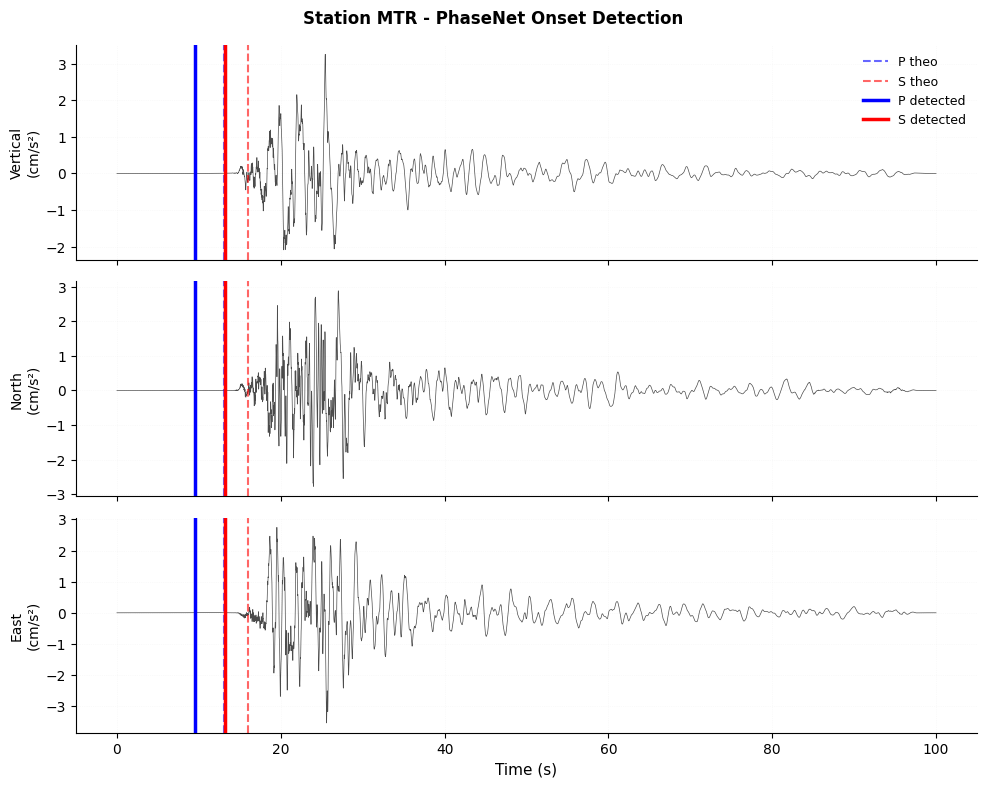

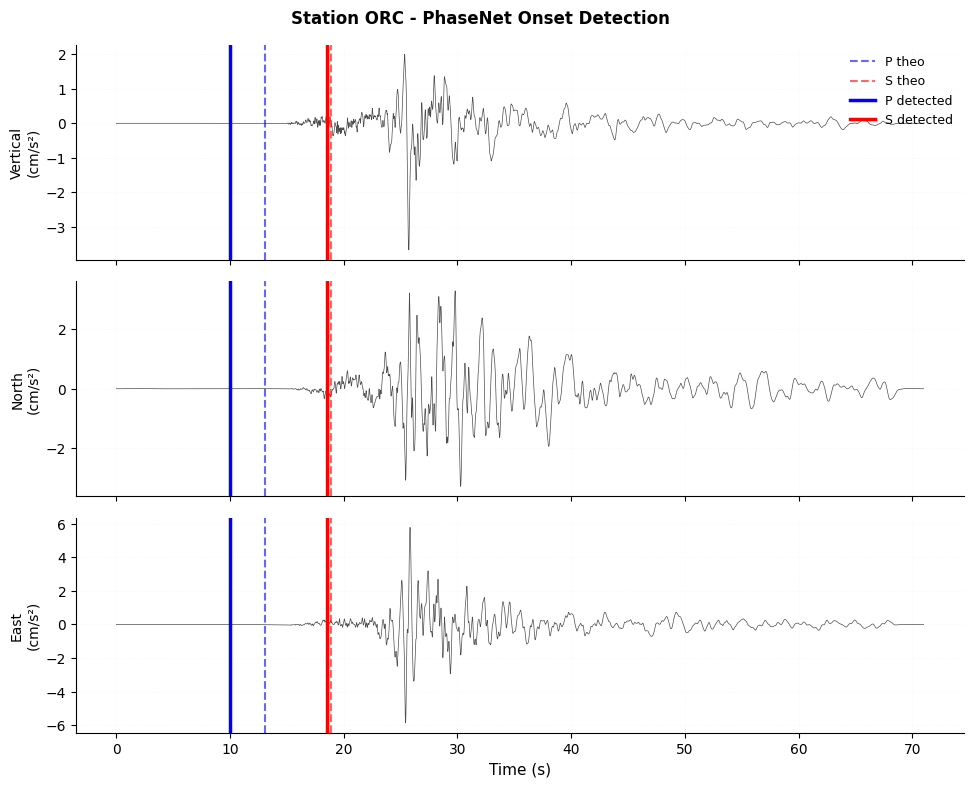

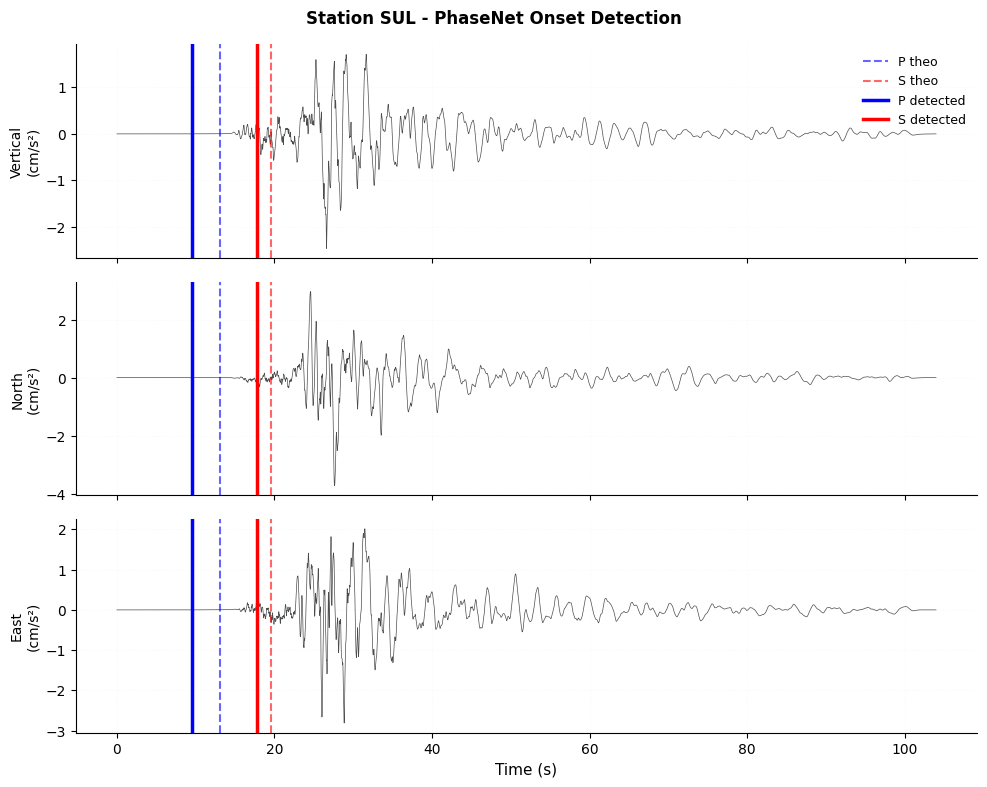

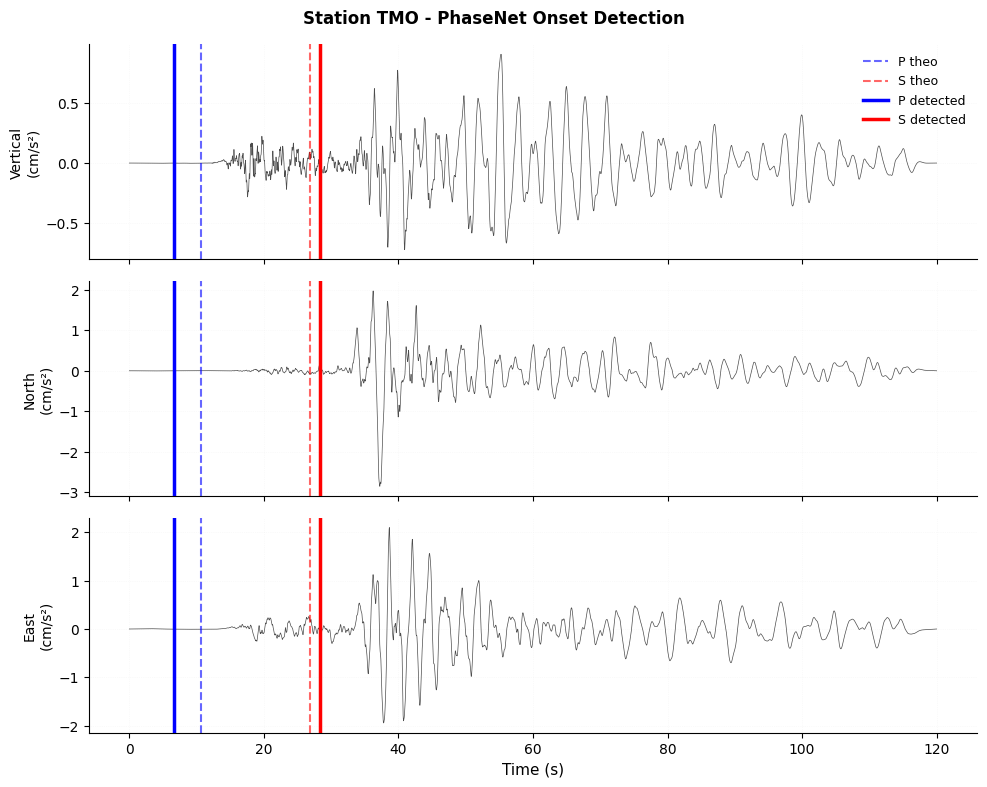

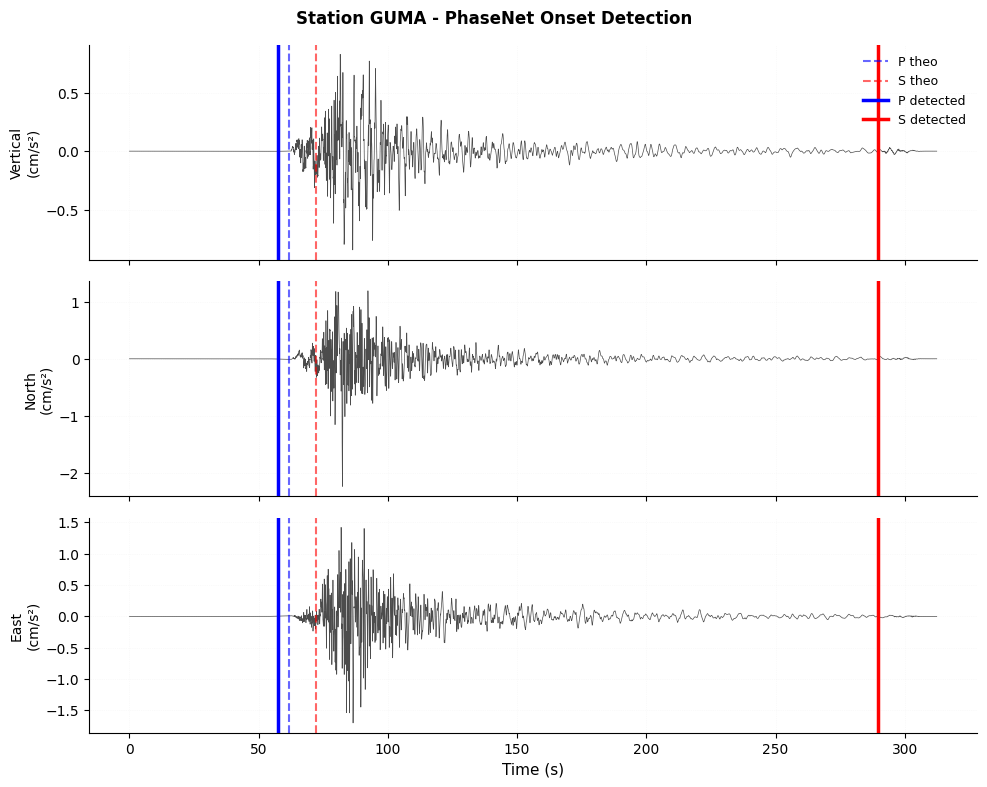

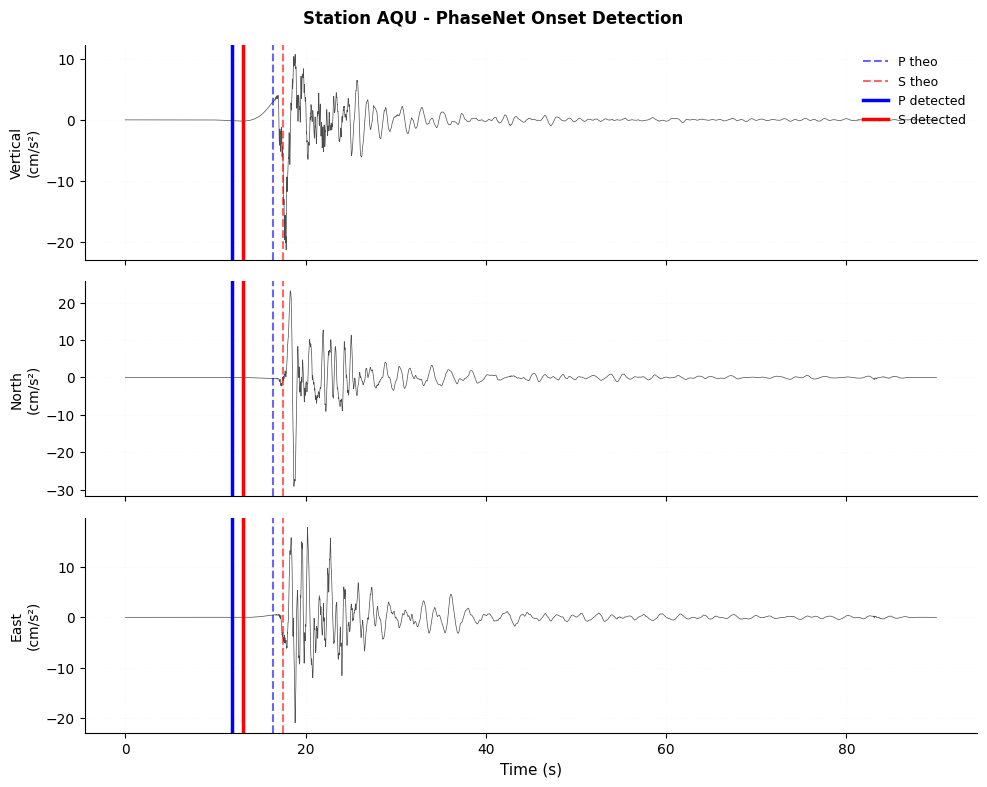

In [43]:
onset_figs= plot_onset_detection_results(
    signals_dict,
    df_meta_stations,
    method='phasenet',
    stations=None,
    output_dir=FIGURES_DIR / 'onset_detection'
)

In [44]:
# Save df_full for sensitivity analysis
df_full_output_file = SIGNALS_PROCESSED_EXPORT / f'df_full_{DATA_TYPE}_phasenet.parquet'
df_full.to_parquet(df_full_output_file, index=False)
logger.info(f"Saved df_full: {df_full_output_file}")
logger.info(f"Shape: {df_full.shape}")
logger.info(f"Columns: {len(df_full.columns)}")

INFO | Saved df_full: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/03b_phase_identification_phasenet/velocity/df_full_velocity_phasenet.parquet
INFO | Shape: (51, 85)
INFO | Columns: 85


## Post event onset detection

In [45]:
df_full = add_coda_end_to_dataframe(
    df_full,
    signals_dict,
    coda_methods=['rautian', 'arias', 'envelope', 'median'],
    threshold_factor=0.10,
    stability_duration=2.0,
    sampling_rate=200,
    smoothing_window=0.5
)


COMPUTING CODA END TIMES
Processing 51 components...
Methods: ['rautian', 'arias', 'envelope', 'median']
Threshold: 10% of S-wave peak amplitude
Stability: 2.0s
Smoothing: 0.5s
Sampling rate: 200 Hz
Working with: t_s_detected_samples

Processing: ...................................................

SUMMARY
Total components processed: 51

Successfully computed:
  rautian     :  30 (58.8%)
  arias       :  51 (100.0%)
  envelope    :  51 (100.0%)
  median      :  51 (100.0%)

Skipped:
No signal data:      0
Missing onsets:      0
Errors:              0

Coda duration statistics:
  Method         Mean   Median      Std  Range                   At signal end
  ---------------------------------------------------------------------------
  rautian      37.46s   35.17s   11.98s  [17.62, 62.01]s             0 at signal end
  arias        21.88s   21.55s    7.50s  [5.88, 34.53]s              3 at signal end
  envelope     31.23s   24.91s   26.09s  [2.02, 140.48]s             6 at signal end
  m

## 13. Window Segmentation

Segment signals into **four non-overlapping windows** using PhaseNet picks:

$$
\begin{aligned}
\text{Pre-event:} & \quad [t_{\text{start}}, t_P) \\\\
\text{P-wave:} & \quad [t_P, t_S) \\\\
\text{S-wave:} & \quad [t_S, t_{\text{coda}}) \\\\
\text{Coda:} & \quad [t_{\text{coda}}, t_{\text{end}}]
\end{aligned}
$$

**Key difference from AR-AIC:**
- PhaseNet picks are **3-5 seconds earlier** → windows shift earlier in time
- **Pre-event window longer** (more noise samples)
- **P-wave window slightly longer** (earlier P pick)
- **S-wave window slightly shorter** (earlier S pick, earlier coda onset)

### Output Structure

Identical to notebook 03a: nested dictionaries with station → component → window → data.

Four separate windowed files created (one per coda method):
- `windowed_{signal_type}_rautian_phasenet.pkl`
- `windowed_{signal_type}_arias_phasenet.pkl`
- `windowed_{signal_type}_envelope_phasenet.pkl`
- `windowed_{signal_type}_median_phasenet.pkl`

**Naming convention:** Files end with `_phasenet.pkl` (vs. `_ar_pick.pkl` for AR-AIC) to distinguish picker methods.

See notebook **03a Section 10** for detailed window definitions and data structure.

In [46]:
for method in ['rautian', 'arias', 'envelope', 'median']:
    logger.info(f"Segmenting signals with {method} coda method...")
    
    # Windowing
    windowed_signals = segment_all_signals(
        signals_dict, 
        df_full, 
        coda_method=method,
        min_window_duration = 2.0
    )
    
    # Save
    output_file = SIGNALS_PROCESSED_EXPORT / f'windowed_{DATA_TYPE}_{method}_phasenet.pkl'
    with open(output_file, 'wb') as f:
        pickle.dump(windowed_signals, f)
    
    logger.info(f"Saved: {output_file}")
    logger.info(f"File size: {output_file.stat().st_size / 1e6:.2f} MB")


    all_stations = list(windowed_signals.keys())
    plot_multiple_stations(
    stations=all_stations,
    signals_dict=signals_dict,
    windowed_signals=windowed_signals,
    df_onsets=df_full,
    coda_method=method,
    output_dir= FIGURES_DIR / f'windows_{method}',
    close_after_save=True 
)

INFO | Segmenting signals with rautian coda method...



SIGNAL SEGMENTATION
Coda method: rautian
Working unit: samples
Sampling rate: 200 Hz
Pre-event strategy: 5.0
Post-event window: ENABLED (using t_coda_end_rautian_samples)

Reading onset columns:
  P-wave: t_p_detected_samples
  S-wave: t_s_detected_samples
  Coda:   t_coda_rautian_samples
  Coda end: t_coda_end_rautian_samples

Processing: Note: Converted pre_p_duration to 1000 samples @ 200Hz
......Error segmenting AQA-HNE: t_s must be < t_coda, got t_s=2500 (12.50s), t_coda=2400 (12.00s)
Error segmenting AQA-HNN: t_s must be < t_coda, got t_s=2500 (12.50s), t_coda=2400 (12.00s)
Error segmenting AQA-HNZ: t_s must be < t_coda, got t_s=2500 (12.50s), t_coda=2400 (12.00s)
Error segmenting AQG-HNE: t_s must be < t_coda, got t_s=5500 (27.50s), t_coda=5400 (27.00s)
Error segmenting AQG-HNN: t_s must be < t_coda, got t_s=5500 (27.50s), t_coda=5400 (27.00s)
Error segmenting AQG-HNZ: t_s must be < t_coda, got t_s=5500 (27.50s), t_coda=5400 (27.00s)
Error segmenting AQK-HNE: t_s must be < t_co

INFO | Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/03b_phase_identification_phasenet/velocity/windowed_velocity_rautian_phasenet.pkl
INFO | File size: 11.44 MB


Error segmenting AQU-HLE: t_s must be < t_coda, got t_s=2622 (13.11s), t_coda=2244 (11.22s)
Error segmenting AQU-HLN: t_s must be < t_coda, got t_s=2622 (13.11s), t_coda=2244 (11.22s)
Error segmenting AQU-HLZ: t_s must be < t_coda, got t_s=2622 (13.11s), t_coda=2244 (11.22s)


SEGMENTATION SUMMARY
Successfully segmented: 36 signals from 17 stations
Skipped (no onset data): 0
Skipped (missing values): 0
Skipped (errors): 15

Windows created:
  pre_event:  33/36
    Missing for: ['TTS']
  p_wave:     33/36
    Missing for: ['TTS']
  s_wave:     30/36
    Missing for: ['GSA', 'TTS']
  coda:       30/36
    Missing for: ['GUMA', 'TTS']
  post_event: 30/36
    Missing for: ['GUMA', 'TTS']

Window duration statistics:

Pre-event:
  Target: 1000 samples (5.00s)
  Actual mean: 5.00s (1000 samp)
  Actual range: [5.00, 5.00]s

P-wave:
  Mean:   27.60s
  Median: 6.35s
  Range:  [2.79, 232.25]s

S-wave:
  Mean:   13.04s
  Median: 9.14s
  Range:  [4.20, 40.31]s

Coda:
  Mean:   37.46s
  Median: 35.

INFO | Segmenting signals with arias coda method...


...



SEGMENTATION SUMMARY
Successfully segmented: 51 signals from 17 stations
Skipped (no onset data): 0
Skipped (missing values): 0
Skipped (errors): 0

Windows created:
  pre_event:  48/51
    Missing for: ['TTS']
  p_wave:     33/51
    Missing for: ['AQA', 'AQG', 'AQK', 'AQU', 'AQV', 'TTS']
  s_wave:     46/51
    Missing for: ['GUMA', 'SUL', 'TTS']
  coda:       51/51
  post_event: 45/51
    Missing for: ['AQA', 'ORC', 'TTS']

Window duration statistics:

Pre-event:
  Target: 1000 samples (5.00s)
  Actual mean: 5.00s (1000 samp)
  Actual range: [5.00, 5.00]s

P-wave:
  Mean:   27.60s
  Median: 6.35s
  Range:  [2.79, 232.25]s

S-wave:
  Mean:   12.42s
  Median: 10.00s
  Range:  [2.96, 81.28]s

Coda:
  Mean:   31.23s
  Median: 24.91s
  Range:  [2.02, 140.48]s

Post-event:
  Mean:   35.22s
  Median: 43.97s
  Range:  [2.44, 60.19]s

Plotting 17 stations...
  Progress: 10/17 stations


INFO | Segmenting signals with median coda method...


  Progress: 17/17 stations
Done! Plotted 17 stations

SIGNAL SEGMENTATION
Coda method: median
Working unit: samples
Sampling rate: 200 Hz
Pre-event strategy: 5.0
Post-event window: ENABLED (using t_coda_end_median_samples)

Reading onset columns:
  P-wave: t_p_detected_samples
  S-wave: t_s_detected_samples
  Coda:   t_coda_median_samples
  Coda end: t_coda_end_median_samples

Processing: Note: Converted pre_p_duration to 1000 samples @ 200Hz
...................................................

INFO | Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/IT-2009-0009/03b_phase_identification_phasenet/velocity/windowed_velocity_median_phasenet.pkl
INFO | File size: 15.00 MB




SEGMENTATION SUMMARY
Successfully segmented: 51 signals from 17 stations
Skipped (no onset data): 0
Skipped (missing values): 0
Skipped (errors): 0

Windows created:
  pre_event:  48/51
    Missing for: ['TTS']
  p_wave:     33/51
    Missing for: ['AQA', 'AQG', 'AQK', 'AQU', 'AQV', 'TTS']
  s_wave:     47/51
    Missing for: ['GUMA', 'TTS']
  coda:       51/51
  post_event: 46/51
    Missing for: ['AQA', 'ORC', 'TTS']

Window duration statistics:

Pre-event:
  Target: 1000 samples (5.00s)
  Actual mean: 5.00s (1000 samp)
  Actual range: [5.00, 5.00]s

P-wave:
  Mean:   27.60s
  Median: 6.35s
  Range:  [2.79, 232.25]s

S-wave:
  Mean:   13.85s
  Median: 10.00s
  Range:  [2.96, 71.44]s

Coda:
  Mean:   26.56s
  Median: 24.40s
  Range:  [2.02, 61.69]s

Post-event:
  Mean:   33.01s
  Median: 42.03s
  Range:  [2.81, 60.19]s

Plotting 17 stations...
  Progress: 10/17 stations
  Progress: 17/17 stations
Done! Plotted 17 stations


## 14. Quality Control

Apply the **same three validation checks** as notebook 03a to enable direct comparison:

### Check 1: Peak Timing
**Criterion:** Peak ground motion should occur in S-wave window.

**Expected performance difference:**
- AR-AIC: ~90% pass rate (picks near peak by design)
- PhaseNet: ~85% pass rate (earlier picks → peak may fall just outside S-window)

---

### Check 2: Monotonicity with Distance
**Criterion:** Arrival times should increase with hypocentral distance.

**Test:** Sort stations by distance, check for violations where $d_i < d_j$ but $t_i > t_j$.

**Expected performance difference:**
- AR-AIC P: ~90% pass rate (search windows constrain picks)
- PhaseNet P: ~85% pass rate (no distance constraint, pure waveform-based)
- AR-AIC S: ~85% pass rate
- PhaseNet S: ~80% pass rate

**Why PhaseNet may violate more:**
PhaseNet has no velocity model constraint → picks purely on waveform features. If lateral velocity heterogeneity exists, PhaseNet may reflect actual travel time variations that violate the 1D model assumption.

---

### Check 3: Signal-to-Noise Ratio (SNR)
**Criterion:** Phase window SNR ≥ 3.

$$\text{SNR} = \frac{\text{RMS}_{\text{signal}}}{\text{RMS}_{\text{noise}}}$$

See notebook **03a Section 11** for detailed explanation of each quality check.

In [47]:
logger.info("Running quality control on windowed signals...")
logger.info("=" * 80)

# Run QC per ogni metodo di coda
qc_results = {}

for method in ['rautian', 'arias', 'envelope', 'median']:
    logger.info(f"\n{method.upper()} METHOD")
    logger.info("-" * 40)
    
    # Load windowed signals
    input_file = SIGNALS_PROCESSED_EXPORT / f'windowed_{DATA_TYPE}_{method}_phasenet.pkl'
    
    if not input_file.exists():
        logger.warning(f"File not found: {input_file}")
        continue
    
    with open(input_file, 'rb') as f:
        windowed_signals = pickle.load(f)
    
    # Run QC
    qc_result = quality_control_all_stations(
        windowed_signals,
        df_full,
        df_meta_stations,
        peak_column=PEAK_COLUMN,
        time_peak_column=TIME_PEAK_COLUMN,
        snr_threshold=3.0,
        coda_method=method
    )
    
    qc_results[method] = qc_result
    
    # Print summary
    print_quality_control_summary(qc_result)

logger.info("\n" + "=" * 80)
logger.info("Quality control complete for all methods")

INFO | Running quality control on windowed signals...
INFO | ================================================================================
INFO | 
RAUTIAN METHOD
INFO | ----------------------------------------
INFO | 
ARIAS METHOD
INFO | ----------------------------------------
INFO | 
ENVELOPE METHOD
INFO | ----------------------------------------
INFO | 
MEDIAN METHOD
INFO | ----------------------------------------
INFO | 
INFO | Quality control complete for all methods



Quality Control Summary

ANT
  ├─ HNE: [✗ Peak] [✗ MonoP] [✓ MonoS] [✓ SNRP] [✓ SNRS]
  ├─ HNN: [✗ Peak] [✗ MonoP] [✓ MonoS] [✓ SNRP] [✓ SNRS]
  └─ HNZ: [✗ Peak] [✗ MonoP] [✓ MonoS] [✓ SNRP] [✓ SNRS]

AQA

AQG

AQK

AQU

AQV

AVZ
  ├─ HNE: [✗ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]
  ├─ HNN: [✗ Peak] [✗ MonoP] [✗ MonoS] [✓ SNRP] [✓ SNRS]
  └─ HNZ: [✗ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]

CLN
  ├─ HNE: [✓ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]
  ├─ HNN: [✓ Peak] [✗ MonoP] [✗ MonoS] [✓ SNRP] [✓ SNRS]
  └─ HNZ: [✓ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]

FMG
  ├─ HNE: [✗ Peak] [✗ MonoP] [✓ MonoS] [✓ SNRP] [✓ SNRS]
  ├─ HNN: [✗ Peak] [✗ MonoP] [✓ MonoS] [✓ SNRP] [✓ SNRS]
  └─ HNZ: [✗ Peak] [✗ MonoP] [✓ MonoS] [✓ SNRP] [✓ SNRS]

GSA
  ├─ HNE: [– Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [– SNRS]
  ├─ HNN: [– Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [– SNRS]
  └─ HNZ: [– Peak] [✗ MonoP] [✗ MonoS] [✓ SNRP] [– SNRS]

GUMA
  ├─ HNE: [✗ Peak] [✗ MonoP] [✗ MonoS] [✗ SNRP] [✓ SNRS]
  ├─ HN

## 15. Summary

This notebook implemented PhaseNet-based phase detection as an alternative to AR-AIC (notebook 03a).

### Processing Pipeline

**Inputs:**
- Preprocessed signals (baseline-corrected, unnormalized)
- Station metadata with coordinates and epicentral distances

**Processing steps:**
1. Load PhaseNet model (INSTANCE pre-trained)
2. Resample signals (200 Hz → 100 Hz)
3. Phase detection (CNN-based picking)
4. Merge with metadata
5. Coda onset detection (4 methods)
6. Window segmentation (4 windows)
7. Quality control (3 validation checks)

**Outputs:**
- `df_full_{signal_type}_phasenet.parquet` — Complete metadata with PhaseNet picks
- `phasenet_picks_{signal_type}.csv` — Raw PhaseNet output
- `windowed_{signal_type}_{coda}_phasenet.pkl` — Segmented signals (4 files)
- Validation figures in `figures/03b_phase_identification_phasenet/{signal_type}/`

---

### Recommendations for Moment Scaling Analysis

**Use both methods:**
1. Run moment scaling on **both AR-AIC and PhaseNet windows**
2. Compare scaling exponents ζ(q) between methods
3. Assess sensitivity to window definition

**Expected impact:**
- **P-wave window:** Minimal difference (both methods similar)
- **S-wave window:** Moderate difference (PhaseNet shorter, may affect ζ(q))
- **Coda window:** Largest difference (timing shift affects Rautian/Envelope)

**If results disagree:**
- Check which method has better QC pass rate for this dataset
- Visual inspection of waveforms (which picker looks more accurate?)
- Consider ensemble: combine picks from both methods

---

### Next Steps

1. Compare PhaseNet vs. AR-AIC picks visually (scatter plots, residuals)
2. Run moment scaling analysis on both picker outputs (notebook 04a)
3. Assess impact of picker choice on scaling exponents
4. Decide on final picker for results (or present both)

**Hypothesis:** Moment scaling exponents should be **robust to moderate window shifts** (3-5 seconds), but we verify this by comparing both methods.